In [1]:
%matplotlib inline
from collections import deque
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

sys.path.append(os.path.abspath(".."))

from Environment.grid import *


VICTIM:
[(18, 6), (17, 8), (15, 10)]

SHELTER:
(18, 18)

FLOOD ORIGINS:
[(9, 9), (9, 10), (10, 9), (10, 10), (11, 9), (11, 10), (12, 9), (12, 10), (15, 8), (15, 9), (16, 8), (16, 9), (17, 8), (17, 9)]

NEIGHBORS OF VICTIM:
(18, 6): [(17, 6), (19, 6), (18, 5), (18, 7)]
(17, 8): [(16, 8), (18, 8), (17, 7), (17, 9)]
(15, 10): [(14, 10), (16, 10), (15, 9), (15, 11)]

CELL INFO (9,9):
{'type': 2, 'water_level': 0.55, 'passable': True}

MOVEMENT COST OF (8,8):
1.0

IS (3,3) PASSABLE?
False


In [2]:
# =====================================================
# A* SEARCH
# =====================================================

import heapq

def astar(start, goal):

    open_list = []

    heapq.heappush(
        open_list,
        (0, start)
    )

    visited = set()

    parent = {}

    parent[start] = None

    g_cost = {}

    g_cost[start] = 0

    while open_list:

        current_f, current = heapq.heappop(
            open_list
        )

        if current in visited:
            continue

        visited.add(current)

        if current == goal:

            path = []

            node = current

            while node is not None:

                path.append(node)

                node = parent[node]

            path.reverse()

            return path

        for neighbor in get_neighbors(current):

            nr, nc = neighbor

            tentative_g = (
                g_cost[current]
                +
                get_cost(nr, nc)
            )

            if (
                neighbor not in g_cost
                or
                tentative_g < g_cost[neighbor]
            ):

                g_cost[neighbor] = tentative_g

                h_cost = heuristic(
                    neighbor,
                    goal
                )

                f_cost = (
                    tentative_g
                    +
                    h_cost
                )

                parent[neighbor] = current

                heapq.heappush(
                    open_list,
                    (
                        f_cost,
                        neighbor
                    )
                )

    return None

In [3]:
# =====================================================
# A* MULTI GOAL
# =====================================================

def astar_multi_goal(start, goals):

    open_list = []

    heapq.heappush(
        open_list,
        (0, start)
    )

    visited = set()

    parent = {}

    parent[start] = None

    g_cost = {}

    g_cost[start] = 0

    goal_set = set(goals)

    while open_list:

        current_f, current = heapq.heappop(
            open_list
        )

        if current in visited:
            continue

        visited.add(current)

        if current in goal_set:

            path = []

            node = current

            while node is not None:

                path.append(node)

                node = parent[node]

            path.reverse()

            return path, current

        for neighbor in get_neighbors(current):

            nr, nc = neighbor

            tentative_g = (
                g_cost[current]
                +
                get_cost(nr, nc)
            )

            if (
                neighbor not in g_cost
                or
                tentative_g < g_cost[neighbor]
            ):

                g_cost[neighbor] = tentative_g

                nearest_goal = min(
                    goals,
                    key=lambda goal:
                    heuristic(
                        neighbor,
                        goal
                    )
                )

                h_cost = heuristic(
                    neighbor,
                    nearest_goal
                )

                f_cost = (
                    tentative_g
                    +
                    h_cost
                )

                parent[neighbor] = current

                heapq.heappush(
                    open_list,
                    (
                        f_cost,
                        neighbor
                    )
                )

    return None, None

Rescue Team Start Position

The rescue team begins from the top-left corner of the environment grid.

The objective is to locate and reach a victim using the A* Search Algorithm.


In [4]:
start = (0, 0)

# Multiple victims -> Multi-goal A*
path_to_victim, found_victim = astar_multi_goal(
    start,
    victims
)

# Shelter is a single goal -> Normal A*
path_to_shelter = astar(
    found_victim,
    shelter
)

if path_to_victim and path_to_shelter:

    full_path = (
        path_to_victim
        +
        path_to_shelter[1:]
    )

    print(
        "Nearest Victim:",
        found_victim
    )

    print(
        "Path to Victim:",
        len(path_to_victim)-1,
        "steps"
    )

    print(
        "Path to Shelter:",
        len(path_to_shelter)-1,
        "steps"
    )

    print(
        "Total Rescue Path:",
        len(full_path)-1,
        "steps"
    )

else:

    print(
        "No valid rescue path found."
    )

Nearest Victim: (18, 6)
Path to Victim: 26 steps
Path to Shelter: 12 steps
Total Rescue Path: 38 steps


Execute A* Search

The A* algorithm is executed to find an optimal path from the rescue team to the nearest victim while considering water depth costs.

After locating the victim, the path is reconstructed and displayed.

In [5]:
path_to_victim, found_victim = astar_multi_goal(
    start,
    victims
)

path_to_shelter = astar(
    found_victim,
    shelter
)

if path_to_victim:

    print("Path Found!")
    print()

    for p in path_to_victim:
        print(p)

    print()

    print(
        "Total Steps:",
        len(path_to_victim)-1
    )

else:

    print("No Path Found!")

if path_to_shelter:

    print("Path Found!")
    print()

    for p in path_to_shelter:
        print(p)

    print()

    print(
        "Total Steps:",
        np.sum([
            len(path_to_victim)-1,
            len(path_to_shelter)-1
        ])
    )

Path Found!

(0, 0)
(0, 1)
(0, 2)
(0, 3)
(0, 4)
(0, 5)
(0, 6)
(1, 6)
(2, 6)
(3, 6)
(4, 6)
(5, 6)
(6, 6)
(7, 6)
(8, 6)
(9, 6)
(10, 6)
(11, 6)
(11, 7)
(12, 7)
(13, 7)
(14, 7)
(15, 7)
(16, 7)
(17, 7)
(17, 6)
(18, 6)

Total Steps: 26
Path Found!

(18, 6)
(18, 7)
(18, 8)
(18, 9)
(18, 10)
(18, 11)
(18, 12)
(18, 13)
(18, 14)
(18, 15)
(18, 16)
(18, 17)
(18, 18)

Total Steps: 38


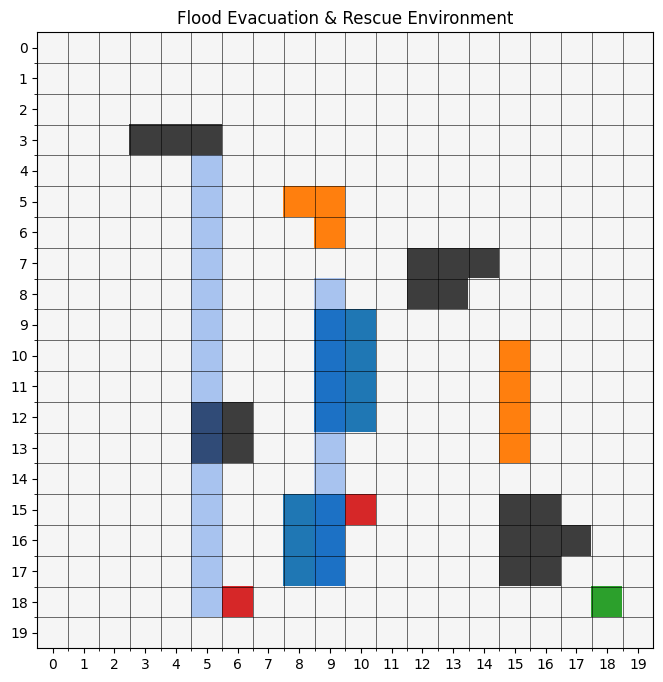

In [6]:
display_grid(save_image=False)

In [7]:
# =====================================================
# TEST A* (START TO NEAREST VICTIM)
# =====================================================

start = (0, 0)

path_to_victim, found_victim = astar_multi_goal(start, victims)

print("\nPATH TO VICTIM (A*):")
print(path_to_victim)

print("\nNearest Victim:", found_victim)
print("Steps:", len(path_to_victim)-1)


PATH TO VICTIM (A*):
[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (1, 6), (2, 6), (3, 6), (4, 6), (5, 6), (6, 6), (7, 6), (8, 6), (9, 6), (10, 6), (11, 6), (11, 7), (12, 7), (13, 7), (14, 7), (15, 7), (16, 7), (17, 7), (17, 6), (18, 6)]

Nearest Victim: (18, 6)
Steps: 26


In [8]:
# =====================================================
# STAGE 2: RISK-A* PATH TO VICTIM
# =====================================================

def display_astar_path_to_victim(path, save_image=True):

    colors = [
        "#f5f5f5",  # ROAD
        "#3d3d3d",  # BUILDING
        "#1f77b4",  # FLOOD
        "#ff7f0e",  # BLOCKED
        "#d62728",  # VICTIM
        "#2ca02c"   # SHELTER
    ]

    cmap = ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(8,8))

    ax.imshow(
        cell_type,
        cmap=cmap,
        vmin=0,
        vmax=5
    )

    overlay = np.zeros((ROWS, COLS, 4))

    for r in range(ROWS):
        for c in range(COLS):

            if (
                RISKY_THRESHOLD
                <
                water_level[r][c]
                <=
                FLOOD_THRESHOLD
            ):

                overlay[r][c] = [
                    0.1,
                    0.4,
                    0.9,
                    0.35
                ]

    ax.imshow(overlay)

    for r, c in path:

        ax.add_patch(
            plt.Rectangle(
                (c, r),
                1,
                1,
                color="cyan",
                alpha=0.4
            )
        )

    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))

    ax.set_xticks(
        [x - 0.5 for x in range(1, COLS)],
        minor=True
    )

    ax.set_yticks(
        [y - 0.5 for y in range(1, ROWS)],
        minor=True
    )

    ax.grid(
        which="minor",
        color="black",
        linewidth=0.4
    )

    ax.set_title(
        "Stage 2: Victim Found (A* Path)"
    )

    if save_image:

        plt.savefig(
            "../images/astar_stage2_victim_found.png",
            bbox_inches="tight"
        )

        print(
            "\nImage Saved: astar_stage2_victim_found.png"
        )

    plt.show()


Image Saved: astar_stage2_victim_found.png


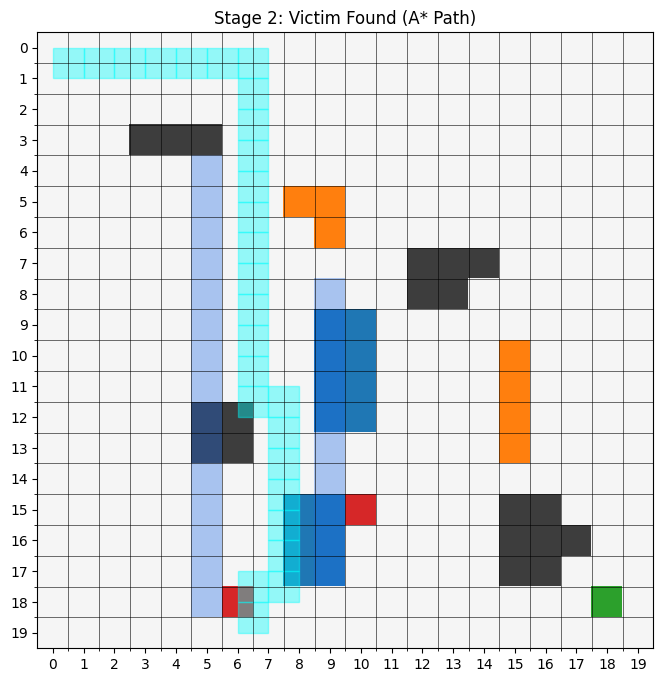

In [9]:
display_astar_path_to_victim(path_to_victim)

In [10]:
# =====================================================
# STAGE 3: FULL RESCUE PATH (VICTIM TO SHELTER) - RISK-A*
# =====================================================

def display_full_rescue_path(full_path, save_image=True):

    colors = [
        "#f5f5f5",  # ROAD
        "#3d3d3d",  # BUILDING
        "#1f77b4",  # FLOOD
        "#ff7f0e",  # BLOCKED
        "#d62728",  # VICTIM
        "#2ca02c"   # SHELTER
    ]

    cmap = ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(8,8))

    ax.imshow(
        cell_type,
        cmap=cmap,
        vmin=0,
        vmax=5
    )

    overlay = np.zeros((ROWS, COLS, 4))

    for r in range(ROWS):
        for c in range(COLS):

            if (
                RISKY_THRESHOLD
                <
                water_level[r][c]
                <=
                FLOOD_THRESHOLD
            ):

                overlay[r][c] = [
                    0.1,
                    0.4,
                    0.9,
                    0.35
                ]

    ax.imshow(overlay)

    for r, c in full_path:

        ax.add_patch(
            plt.Rectangle(
                (c, r),
                1,
                1,
                color="green",
                alpha=0.4
            )
        )

    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))

    ax.set_xticks(
        [x - 0.5 for x in range(1, COLS)],
        minor=True
    )

    ax.set_yticks(
        [y - 0.5 for y in range(1, ROWS)],
        minor=True
    )

    ax.grid(
        which="minor",
        color="black",
        linewidth=0.4
    )

    ax.set_title(
        "Stage 3: Full Rescue Completed (A*)"
    )

    if save_image:

        plt.savefig(
            "../images/astar_stage3_full_rescue.png",
            bbox_inches="tight"
        )

        print(
            "\nImage Saved: astar_stage3_full_rescue.png"
        )

    plt.show()


Image Saved: astar_stage3_full_rescue.png


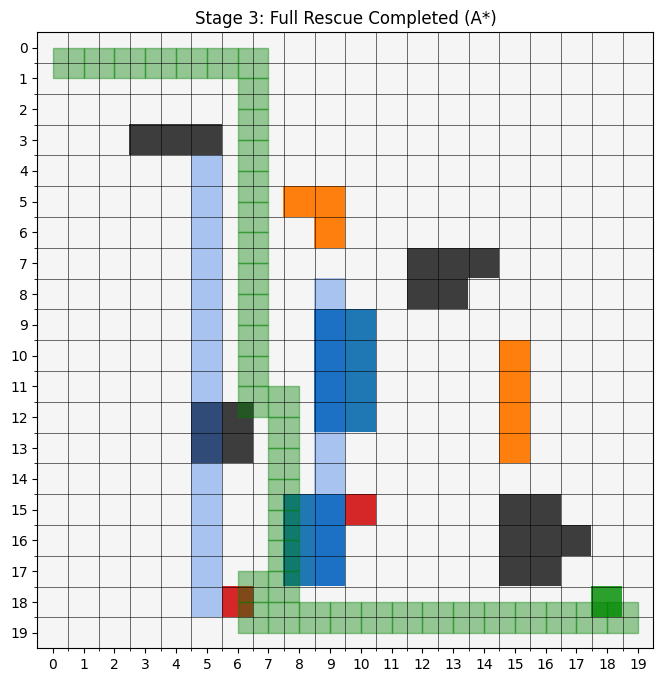

In [11]:
display_full_rescue_path(full_path)

In [12]:
reset_grid()